# EN3150 – Assignment 01

**Learning from Data and Related Challenges and Linear Models for Regression**

**Index No:** 210210G

**Name:** Hasaranga T.N.

**Date:** August 2025

## 1. Linear Regression Impact on Outliers

### Task 2 – Linear Regression Model

Using the given dataset, the least squares regression line is:

$$
y = -3.55x + 3.92
$$

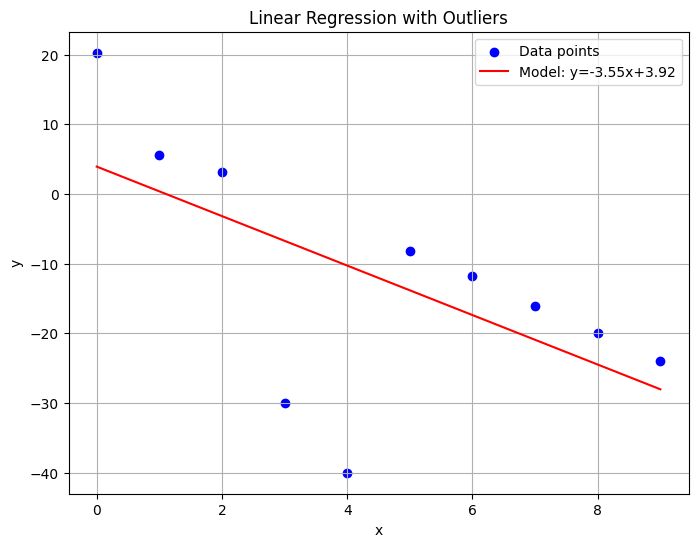

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
x = np.array([0,1,2,3,4,5,6,7,8,9])
y = np.array([20.26,5.61,3.14,-30.00,-40.00,-8.13,-11.73,-16.08,-19.95,-24.03])

# Model
y_pred= -3.55*x + 3.92

# Plot
plt.figure(figsize=(8,6))
plt.scatter(x, y, color="blue", label="Data points")
plt.plot(x, y_pred, "r-", label="Model: y=-3.55x+3.92")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with Outliers")
plt.legend()
plt.grid(True)
plt.show()

### Task 4 – Loss Function Values

The robust loss values for the two models with different β values are shown below:

| β    | Model 1 Loss | Model 2 Loss |
| ---- | ------------ | ------------ |
| 1    | 0.4354       | 0.9728       |
| 1e-6 | 1.0000       | 1.0000       |
| 1000 | 0.000227     | 0.000188     |

In [4]:
import pandas as pd

# Models
y_pred_model1 = -4*x + 12
y_pred_model2 = -3.55*x + 3.91

# Robust loss function
def robust_loss(y_true, y_pred, beta):
    residuals = y_true - y_pred
    return np.mean((residuals**2) / (residuals**2 + beta**2))

# Compute losses
betas = [1, 1e-6, 1e3]
loss_results = []

for beta in betas:
    l1 = robust_loss(y, y_pred_model1, beta)
    l2 = robust_loss(y, y_pred_model2, beta)
    loss_results.append([beta, l1, l2])

loss_df = pd.DataFrame(loss_results, columns=["Beta", "Model 1 Loss", "Model 2 Loss"])
print(loss_df)

          Beta  Model 1 Loss  Model 2 Loss
0     1.000000      0.435416      0.972847
1     0.000001      1.000000      1.000000
2  1000.000000      0.000227      0.000188


### Task 5 – Suitable β

The suitable β value is **1**, as it balances sensitivity to normal points and robustness to outliers.

### Task 6 – Suitable Model

With β = 1, **Model 2** gives a lower loss. Therefore, Model 2 is the more suitable choice.

### Task 7 – How the Robust Estimator Reduces Outliers

* Outliers normally create very large squared errors.
* The robust loss normalizes residuals using $(r^2 + β^2)$.
* Large errors saturate near 1 instead of growing indefinitely.
* Thus, the influence of outliers is **down-weighted** while normal points guide the fit.

### Task 8 – Another Loss Function

Another robust loss function is the **Huber Loss**, which is quadratic for small errors but linear for large errors, making it less sensitive to outliers.

## 2. Loss Function

### Task 1 – MSE and BCE Table (y = 1)

| True y | Prediction ŷ | MSE    | BCE    |
| ------ | ------------ | ------ | ------ |
| 1      | 0.005        | 0.9900 | 5.2983 |
| 1      | 0.01         | 0.9801 | 4.6052 |
| 1      | 0.05         | 0.9025 | 2.9957 |
| 1      | 0.1          | 0.8100 | 2.3026 |
| 1      | 0.2          | 0.6400 | 1.6094 |
| 1      | 0.3          | 0.4900 | 1.2040 |
| 1      | 0.4          | 0.3600 | 0.9163 |
| 1      | 0.5          | 0.2500 | 0.6931 |
| 1      | 0.6          | 0.1600 | 0.5108 |
| 1      | 0.7          | 0.0900 | 0.3567 |
| 1      | 0.8          | 0.0400 | 0.2231 |
| 1      | 0.9          | 0.0100 | 0.1054 |
| 1      | 1.0          | 0.0000 | 0.0000 |

    True y  Prediction y_hat       MSE       BCE
0        1             0.005  0.990025  5.298317
1        1             0.010  0.980100  4.605170
2        1             0.050  0.902500  2.995732
3        1             0.100  0.810000  2.302585
4        1             0.200  0.640000  1.609438
5        1             0.300  0.490000  1.203973
6        1             0.400  0.360000  0.916291
7        1             0.500  0.250000  0.693147
8        1             0.600  0.160000  0.510826
9        1             0.700  0.090000  0.356675
10       1             0.800  0.040000  0.223144
11       1             0.900  0.010000  0.105361
12       1             1.000  0.000000  0.000000


C:\Users\User\AppData\Local\Temp\ipykernel_16404\4072017806.py:7: RuntimeWarning: divide by zero encountered in log
  bce_vals = -(y_true_bin*np.log(preds) + (1-y_true_bin)*np.log(1-preds))
C:\Users\User\AppData\Local\Temp\ipykernel_16404\4072017806.py:7: RuntimeWarning: invalid value encountered in multiply
  bce_vals = -(y_true_bin*np.log(preds) + (1-y_true_bin)*np.log(1-preds))


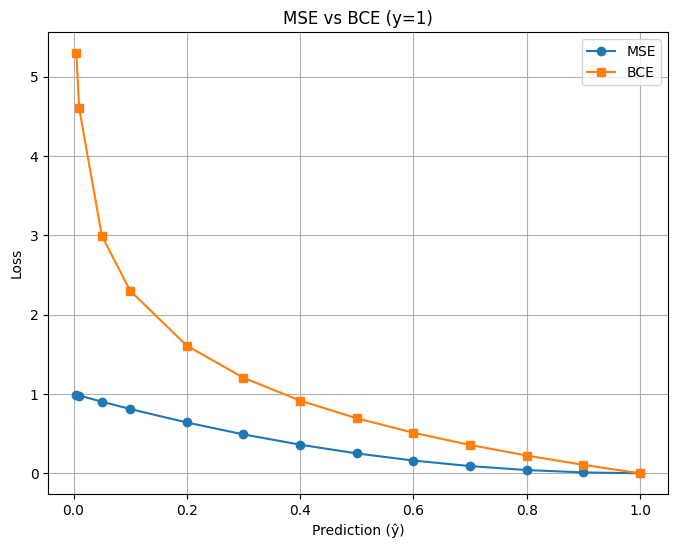

In [4]:
# Predictions
preds = np.array([0.005,0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
y_true_bin = 1

# Loss calculations
mse_vals = (y_true_bin - preds)**2
bce_vals = -(y_true_bin*np.log(preds) + (1-y_true_bin)*np.log(1-preds))
bce_vals[-1] = 0.0  # Fix BCE at y_hat=1.0

# Create DataFrame
mse_bce_df = pd.DataFrame({
    "True y": [1]*len(preds),
    "Prediction y_hat": preds,
    "MSE": mse_vals,
    "BCE": bce_vals
})
print(mse_bce_df)

# Plot
plt.figure(figsize=(8,6))
plt.plot(preds, mse_vals, "o-", label="MSE")
plt.plot(preds, bce_vals, "s-", label="BCE")
plt.xlabel("Prediction (ŷ)")
plt.ylabel("Loss")
plt.title("MSE vs BCE (y=1)")
plt.legend()
plt.grid(True)
plt.show()

### Task 2 – Choice of Loss Function

* For **Application 1** (continuous output): use **MSE**.
* For **Application 2** (binary output): use **BCE**, since it models probabilities effectively.

## 3. Data Pre-processing

C:\Users\User\AppData\Local\Temp\ipykernel_4576\2262310105.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sparse_signal[10] = np.random.randn(1) + 30


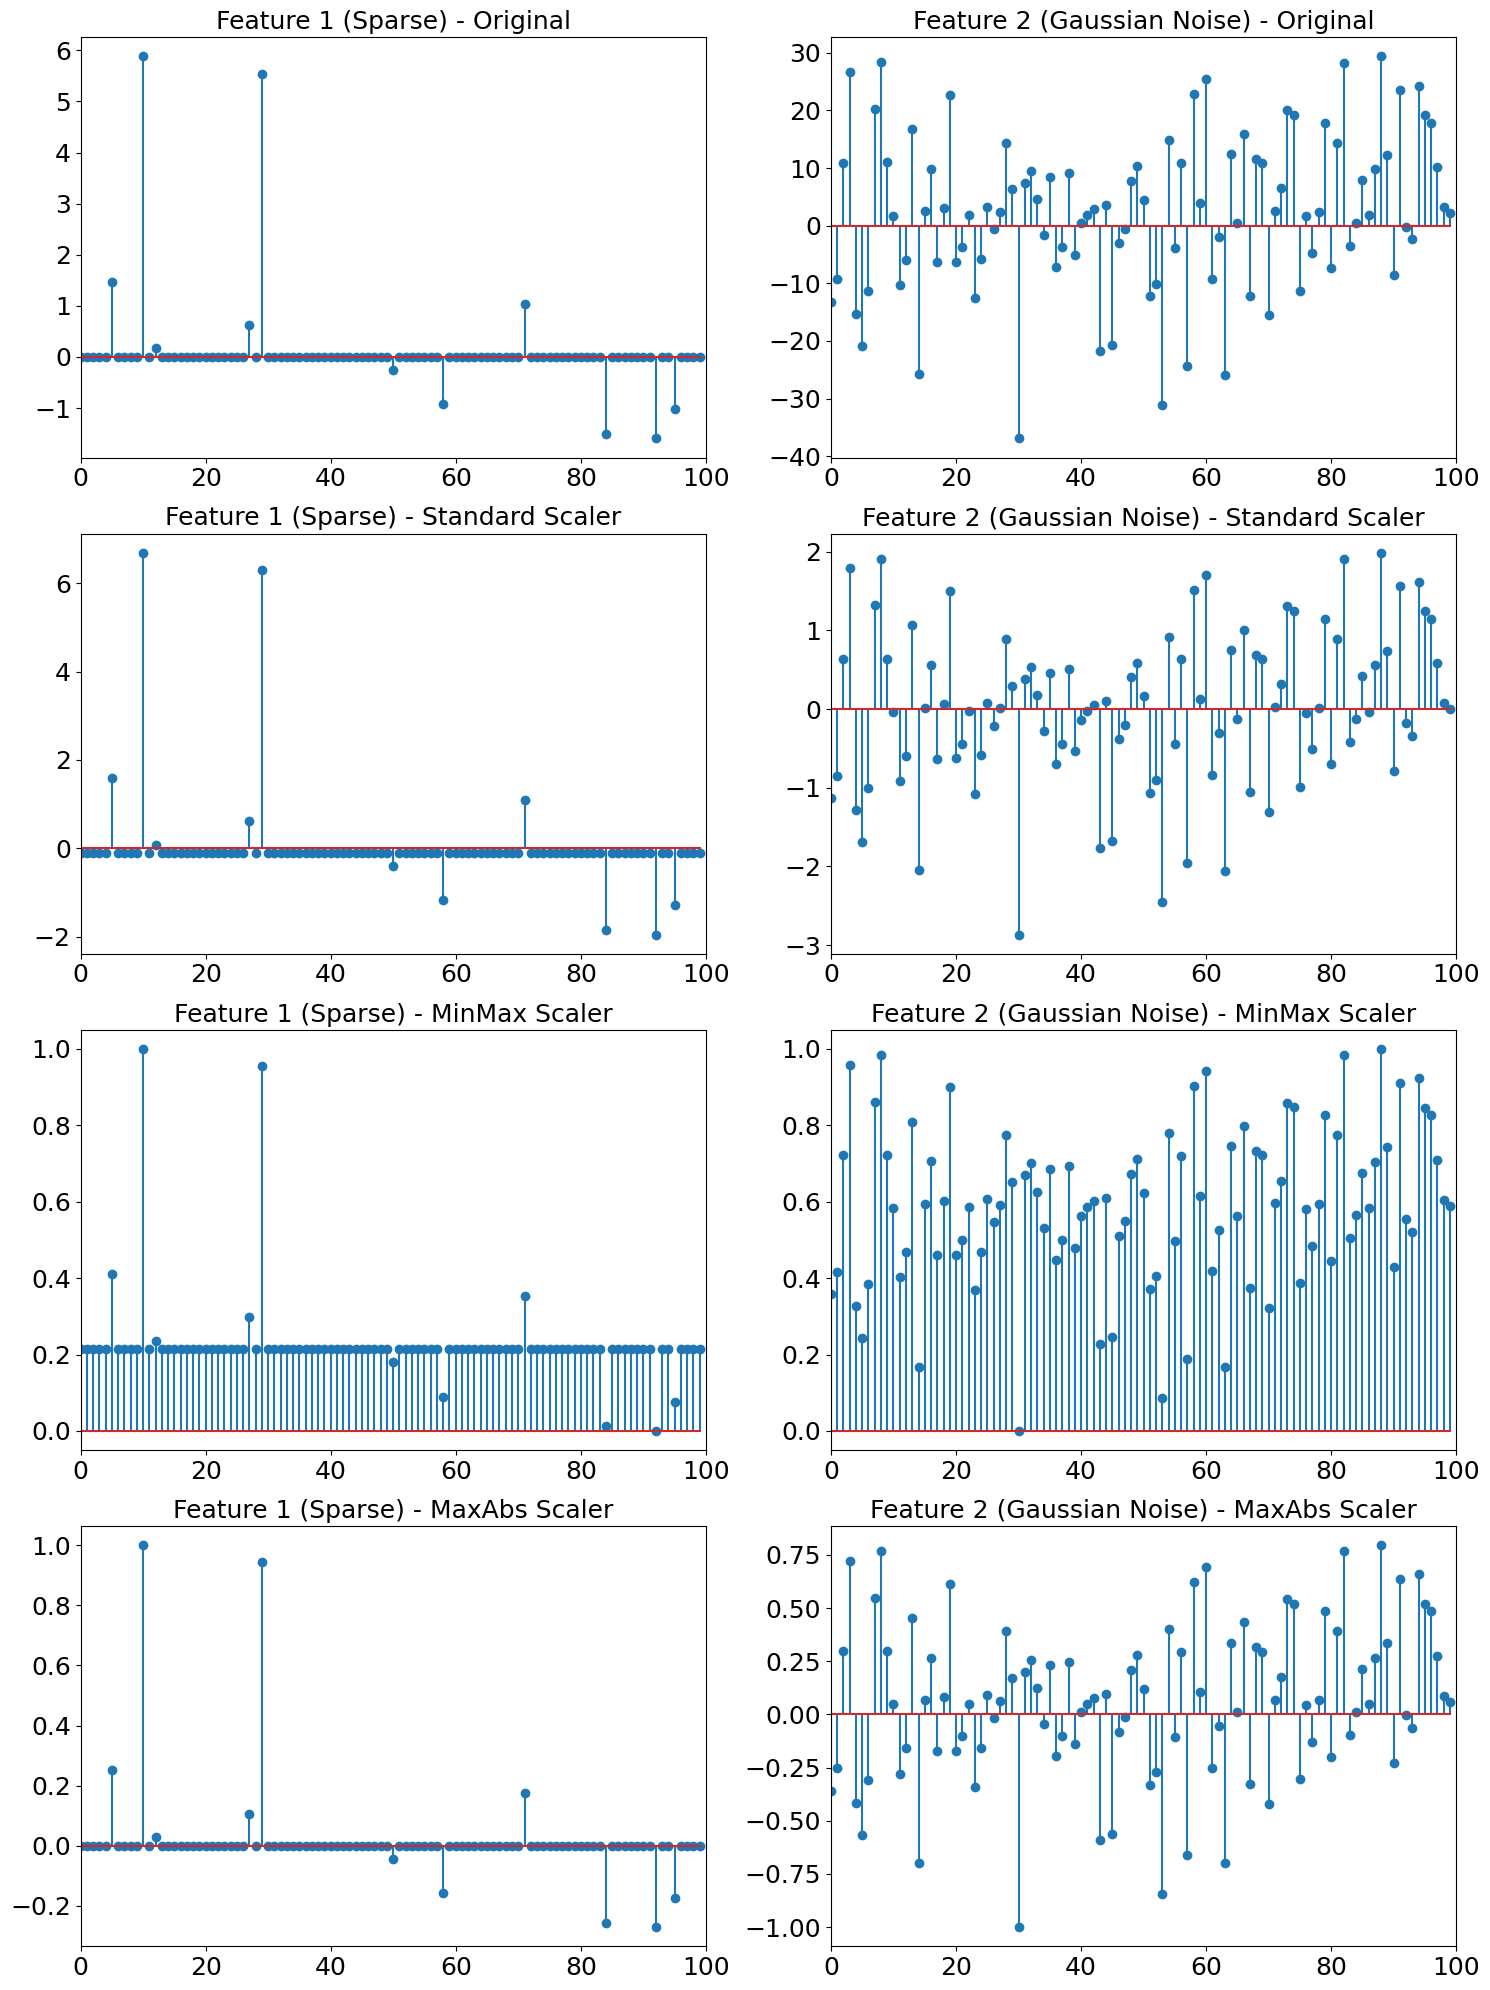

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

def generate_signal(signal_length, num_nonzero):
    signal = np.zeros(signal_length)
    nonzero_indices = np.random.choice(signal_length, num_nonzero, replace=False)
    nonzero_values = 10 * np.random.randn(num_nonzero)
    signal[nonzero_indices] = nonzero_values
    return signal

signal_length = 100
num_nonzero = 10
your_index_no = 210210 # Index No
sparse_signal = generate_signal(signal_length, num_nonzero)
sparse_signal[10] = (your_index_no % 10) * 2 + 10
if your_index_no % 10 == 0:
    sparse_signal[10] = np.random.randn(1) + 30
sparse_signal = sparse_signal / 5
epsilon = np.random.normal(0, 15, signal_length)

# Reshape the signals for scaling
sparse_signal_reshaped = sparse_signal.reshape(-1, 1)
epsilon_reshaped = epsilon.reshape(-1, 1)

# Initialize the scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
maxabs_scaler = MaxAbsScaler()

# Apply the scalers to the sparse signal (Feature 1)
sparse_signal_standard_scaled = standard_scaler.fit_transform(sparse_signal_reshaped)
sparse_signal_minmax_scaled = minmax_scaler.fit_transform(sparse_signal_reshaped)
sparse_signal_maxabs_scaled = maxabs_scaler.fit_transform(sparse_signal_reshaped)

# Apply the scalers to the Gaussian noise signal (Feature 2)
epsilon_standard_scaled = standard_scaler.fit_transform(epsilon_reshaped)
epsilon_minmax_scaled = minmax_scaler.fit_transform(epsilon_reshaped)
epsilon_maxabs_scaled = maxabs_scaler.fit_transform(epsilon_reshaped)

# Plotting
plt.figure(figsize=(15, 20))

# Original Features
plt.subplot(4, 2, 1)
plt.xlim(0, signal_length)
plt.title("Feature 1 (Sparse) - Original", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.stem(sparse_signal)

plt.subplot(4, 2, 2)
plt.xlim(0, signal_length)
plt.title("Feature 2 (Gaussian Noise) - Original", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.stem(epsilon)

# StandardScaler
plt.subplot(4, 2, 3)
plt.xlim(0, signal_length)
plt.title("Feature 1 (Sparse) - Standard Scaler", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.stem(sparse_signal_standard_scaled)

plt.subplot(4, 2, 4)
plt.xlim(0, signal_length)
plt.title("Feature 2 (Gaussian Noise) - Standard Scaler", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.stem(epsilon_standard_scaled)

# MinMaxScaler
plt.subplot(4, 2, 5)
plt.xlim(0, signal_length)
plt.title("Feature 1 (Sparse) - MinMax Scaler", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.stem(sparse_signal_minmax_scaled)

plt.subplot(4, 2, 6)
plt.xlim(0, signal_length)
plt.title("Feature 2 (Gaussian Noise) - MinMax Scaler", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.stem(epsilon_minmax_scaled)

# MaxAbsScaler
plt.subplot(4, 2, 7)
plt.xlim(0, signal_length)
plt.title("Feature 1 (Sparse) - MaxAbs Scaler", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.stem(sparse_signal_maxabs_scaled)

plt.subplot(4, 2, 8)
plt.xlim(0, signal_length)
plt.title("Feature 2 (Gaussian Noise) - MaxAbs Scaler", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.stem(epsilon_maxabs_scaled)

plt.tight_layout()
plt.show()

* **Feature 1 (Sparse signal):** Best scaled with **Max-Abs Scaling**, because it preserves sparsity and zero entries.
* **Feature 2 (Gaussian noise):** Best scaled with **Standard Scaling**, because it ensures mean = 0 and variance = 1, preserving distribution.

Thus, the chosen scaling methods preserve the structure and properties of both features.